In [1]:
import os
import json
import shutil
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.special as special

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torch.optim import lr_scheduler
import torch.nn.functional as F

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from datasets import *
from model import *
import shap
import matplotlib.pyplot as plt

try:
    from torchsummary import summary
except Exception:
    summary = None

/Users/mzhou16/anaconda3/envs/satmoc_ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment / output configuration

In [2]:
MODEL_NAME = "O3_MLP_training"

BASE_SAVE_DIR = Path("./")
MODEL_PATH = BASE_SAVE_DIR / MODEL_NAME
SAVE_PATH = MODEL_PATH / "MLP_SAVE_DATA"
CHECK_PATH = MODEL_PATH / "MLP_CHECK_POINT"

SAVE_ON = True


# -----------------------------------------------------------------------------
# Ozone input file
# -----------------------------------------------------------------------------
data_dir = './DATA/'
filename = '2023_clean.csv'
DATA_FILE = Path(f"{data_dir}{filename}")


## Data filtering configuration
Acceptable ozone range in the original physical unit.


In [3]:
# Acceptable ozone range in the original physical unit.
ozone_valid_range = (0.0, 600.0)

## Label and feature configuration

In [4]:
# Target variable.
label_name = ["epa_o3"]

# Continuous predictors.
# These variables will be Gaussian-normalized.
feat_name = [
    "latitude",
    "longitude",
    "aster_dem",

    "cams_col_o3",
    "cams_surf_o3",
    "cams_surf_no2",
    "cams_surf_hcho",

    "ceres_swf_all",

    "era5_blh",
    "era5_t2m",
    "era5_u10",
    "era5_v10",
    "era5_t2m-d2m",

    "water_fraction",
    "modis_ndvi",

    "pop",
    "viirs_ntl",

    "doy",
    "year",
]

# Categorical predictors.
# These should not be Gaussian-normalized directly.
# They should usually be one-hot encoded.
categorical_feat_name = [
    "modis_landtype",
]

## Data split configuration

In [5]:
validation_split = 0.2
test_split = 0.1
random_seed = 42

## Model architecture configuration

In [6]:
# Hidden-layer sizes for the MLP.
inner_layer = [512, 512, 512, 16]

## Training configuration

In [7]:
batch_size = 16000
learning_rate = 0.05
EPOCHS = 10

gamma = 0.5
min_lr = 1e-4

In [8]:
# =============================================================================
# Main script
# =============================================================================
print(f" - Making {MODEL_PATH}")
if MODEL_PATH.exists():
    shutil.rmtree(MODEL_PATH)
SAVE_PATH.mkdir(parents=True, exist_ok=True)
CHECK_PATH.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" - Using {device} device")



print("=" * 90)
print("                                  - Data manipulating -")
print("=" * 90)

# Columns to read. Keeping this explicit makes missing-column errors easier to diagnose.
read_vars = sorted(set(label_name + feat_name + categorical_feat_name))

label, feat, label_dict, feature_dict, order_feat = read_ozone_data(
    DATA_FILE,
    read_vars,
    label_name,
    feat_name,
    categorical_feat_name=categorical_feat_name,
    ozone_valid_range=ozone_valid_range,
)

_, n_feat = np.shape(feat)
_, n_label = np.shape(label)

 - Making O3_MLP_training
 - Using cuda device
                                  - Data manipulating -
 - Reading DATA/2023_clean.csv
 - Feature configuration
   Number of continuous features : 19
   Number of categorical features: 1
   Number of one-hot features    : 15
   Total model input features    : 34
   Feature order:
      01. latitude
      02. longitude
      03. aster_dem
      04. cams_col_o3
      05. cams_surf_o3
      06. cams_surf_no2
      07. cams_surf_hcho
      08. ceres_swf_all
      09. era5_blh
      10. era5_t2m
      11. era5_u10
      12. era5_v10
      13. era5_t2m-d2m
      14. water_fraction
      15. modis_ndvi
      16. pop
      17. viirs_ntl
      18. doy
      19. year
      20. modis_landtype_1
      21. modis_landtype_10
      22. modis_landtype_11
      23. modis_landtype_12
      24. modis_landtype_13
      25. modis_landtype_14
      26. modis_landtype_16
      27. modis_landtype_17
      28. modis_landtype_2
      29. modis_landtype_4
      30. 

In [9]:
train_indices, val_indices, test_indices = split_data(
    label, feat, validation_split, test_split, random_seed=random_seed
)

print(" - Forming training data set")
data_train = OzoneDataset(label[train_indices], feat[train_indices])
print(" - Forming validation data set")
data_val = OzoneDataset(label[val_indices], feat[val_indices])
print(" - Forming test data set")
data_test = OzoneDataset(label[test_indices], feat[test_indices])

train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(data_val, batch_size=batch_size, shuffle=True)

 - Receive 375368 data
 - Split 70.0% to training, 20.0% to validation, 10.0% to test
 - training: 262757, validation: 75074, test: 37537
 - Forming training data set
 - Shape of the label: torch.Size([262757, 1])
 - Shape of the features: torch.Size([262757, 34])
 - Forming validation data set
 - Shape of the label: torch.Size([75074, 1])
 - Shape of the features: torch.Size([75074, 34])
 - Forming test data set
 - Shape of the label: torch.Size([37537, 1])
 - Shape of the features: torch.Size([37537, 34])


In [10]:
layers = np.array([n_feat] + inner_layer + [n_label])

model = MLPRegressor(layers)
model.to(device)

if summary is not None:
    summary(model, (n_feat,))
else:
    print(" - torchsummary is not installed; skip model summary.")


ModuleList(
  (0): Linear(in_features=34, out_features=512, bias=True)
  (1-2): 2 x Linear(in_features=512, out_features=512, bias=True)
  (3): Linear(in_features=512, out_features=16, bias=True)
  (4): Linear(in_features=16, out_features=1, bias=True)
)
 - torchsummary is not installed; skip model summary.


In [11]:
optimizer = SGD(model.parameters(), lr=learning_rate, momentum=0.0)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=gamma,
    min_lr=min_lr,
)

In [12]:
from train import *
print("=" * 90)
print("                                  - Train model -")
print("=" * 90)
print(f" - Model name: {MODEL_NAME}")
print(f" - Random seed: {random_seed}\n - Batch size: {batch_size}")

lr = scheduler.optimizer.param_groups[0]["lr"]

train_targets = train_preds = None
valid_targets = valid_preds = None

history = {
    "epoch": [],
    "lr": [],

    "train_r2": [],
    "train_mae": [],
    "train_mse": [],
    "train_rmse": [],
    "train_mb": [],

    "valid_r2": [],
    "valid_mae": [],
    "valid_mse": [],
    "valid_rmse": [],
    "valid_mb": [],
}



now_1 = datetime.datetime.now()

for epoch in range(EPOCHS):
    print("=" * 90)
    now = datetime.datetime.now()
    delta_time = now - now_1
    print(f"[INFO] epoch: {epoch + 1}...", now, " Time consume", f"{delta_time.seconds:3.0f}s")
    now_1 = now

    train_targets, train_preds, train_r2, train_mae, train_mse, train_rmse, train_mb = train_one_epoch(
        epoch, model, train_loader, optimizer, device, label_dict[label_name[0]], lr
    )
    
    valid_targets, valid_preds, valid_r2, valid_mae, valid_mse, valid_rmse, valid_mb = validation(
        epoch, model, validation_loader, device, label_dict[label_name[0]], lr
    )

    # ------------------------------------------------------------
    # Record epoch-level statistics
    # ------------------------------------------------------------
    history["epoch"].append(epoch + 1)
    history["lr"].append(lr)

    history["train_r2"].append(train_r2)
    history["train_mae"].append(train_mae)
    history["train_mse"].append(train_mse)
    history["train_rmse"].append(train_rmse)
    history["train_mb"].append(train_mb)

    history["valid_r2"].append(valid_r2)
    history["valid_mae"].append(valid_mae)
    history["valid_mse"].append(valid_mse)
    history["valid_rmse"].append(valid_rmse)
    history["valid_mb"].append(valid_mb)

    
    scheduler.step(valid_mae)
    lr = scheduler.optimizer.param_groups[0]["lr"]

test_targets, test_preds, test_r2, test_mae, test_mse, test_rmse, test_mb= test(
    model, data_test, device, label_dict[label_name[0]]
)


                                  - Train model -
 - Model name: O3_MLP_training
 - Random seed: 42
 - Batch size: 16000
[INFO] epoch: 1... 2026-06-25 11:55:12.840811  Time consume   0s
Train: 1 LR: 0.05000, r2_scores: 0.37 mae_scores: 7.460 mse_scores: 95.240 rmse_scores: 9.759 mb_scores: 0.273
Evaluate: 1 LR: 0.05000, r2_scores: 0.571 mae_scores: 6.089 mse_scores: 64.737 rmse_scores: 8.046 mb_scores: 0.087
[INFO] epoch: 2... 2026-06-25 11:55:15.704208  Time consume   2s
Train: 2 LR: 0.05000, r2_scores: 0.56 mae_scores: 6.188 mse_scores: 66.127 rmse_scores: 8.132 mb_scores: -0.032
Evaluate: 2 LR: 0.05000, r2_scores: 0.613 mae_scores: 5.737 mse_scores: 58.294 rmse_scores: 7.635 mb_scores: -0.941
[INFO] epoch: 3... 2026-06-25 11:55:18.511535  Time consume   2s
Train: 3 LR: 0.05000, r2_scores: 0.62 mae_scores: 5.689 mse_scores: 57.152 rmse_scores: 7.560 mb_scores: 0.011
Evaluate: 3 LR: 0.05000, r2_scores: 0.611 mae_scores: 5.816 mse_scores: 58.701 rmse_scores: 7.662 mb_scores: 2.252
[INF

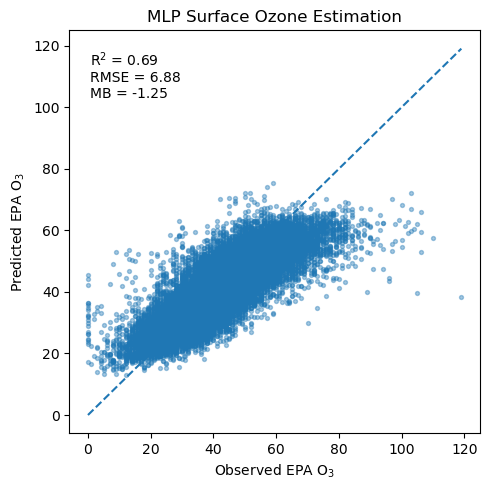

In [13]:

plt.figure(figsize=(5, 5))
plt.scatter(test_targets, test_preds, s=8, alpha=0.4)

min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed EPA O$_3$")
plt.ylabel("Predicted EPA O$_3$")
plt.title("MLP Surface Ozone Estimation")

plt.text(
    0.05, 0.95,
    f"R$^2$ = {test_r2:.2f}\nRMSE = {test_rmse:.2f}\nMB = {test_mb:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()



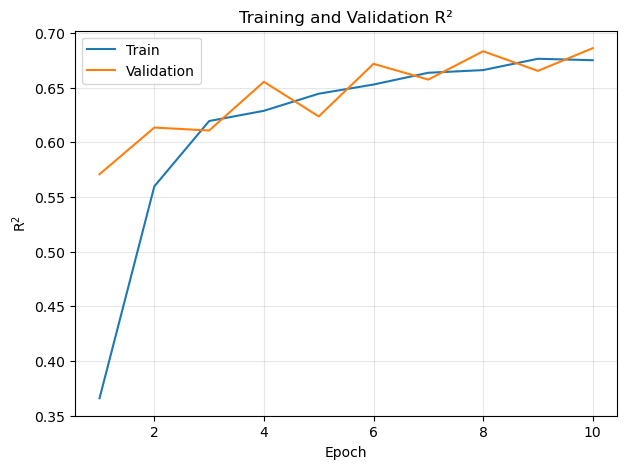

In [14]:

epochs = history["epoch"]
# ------------------------------------------------------------
# R2
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_r2"], label="Train")
plt.plot(epochs, history["valid_r2"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("R$^2$")
plt.title("Training and Validation R²")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()




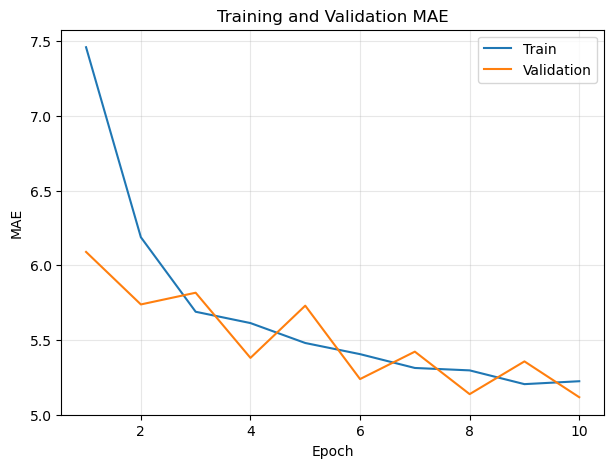

In [15]:
epochs = history["epoch"]
# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_mae"], label="Train")
plt.plot(epochs, history["valid_mae"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


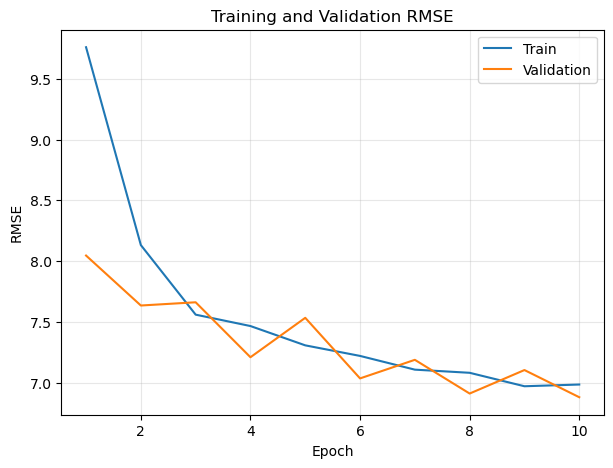

In [16]:
epochs = history["epoch"]
# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_rmse"], label="Train")
plt.plot(epochs, history["valid_rmse"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training and Validation RMSE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



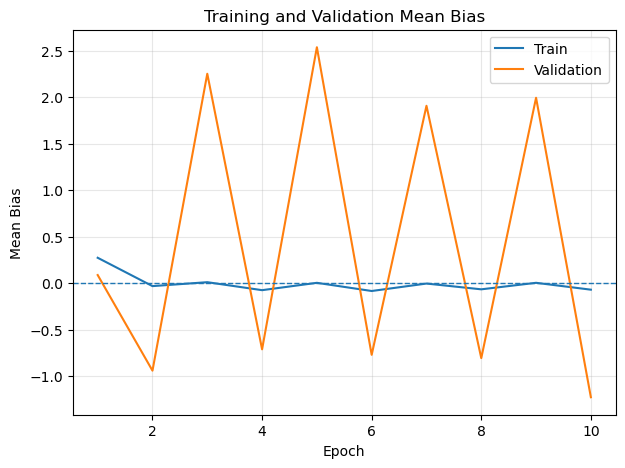

In [17]:
epochs = history["epoch"]
# ------------------------------------------------------------
# Mean Bias
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_mb"], label="Train")
plt.plot(epochs, history["valid_mb"], label="Validation")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Mean Bias")
plt.title("Training and Validation Mean Bias")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


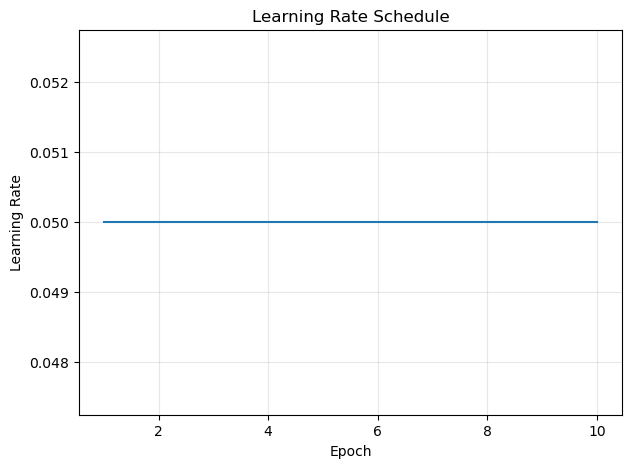

In [18]:
epochs = history["epoch"]
# ------------------------------------------------------------
# Learning rate
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs, history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True, alpha=0.3)

plt.show()

                                  - SHAP analysis -
 - Background samples : 200
 - Explained samples  : 1000
 - Number of features : 34
 - SHAP values shape  : (1000, 34)

 - Top SHAP features
          feature  mean_abs_shap  mean_shap
     cams_surf_o3       0.442053   0.025909
    ceres_swf_all       0.202933  -0.011762
        aster_dem       0.086047   0.005678
    cams_surf_no2       0.084400  -0.006491
              doy       0.083020  -0.008946
       modis_ndvi       0.074577   0.002574
         era5_v10       0.053956   0.004346
         era5_t2m       0.051727  -0.008052
   water_fraction       0.049842  -0.002394
         latitude       0.045715  -0.003559
         era5_u10       0.045151   0.000383
   cams_surf_hcho       0.043044  -0.001848
        longitude       0.039681   0.005096
         era5_blh       0.033200  -0.000261
     era5_t2m-d2m       0.030076   0.011806
      cams_col_o3       0.027236   0.002071
        viirs_ntl       0.024250  -0.001061
modis_landtype_

/tmp/ipykernel_87878/3119994358.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_87878/3119994358.py:137: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


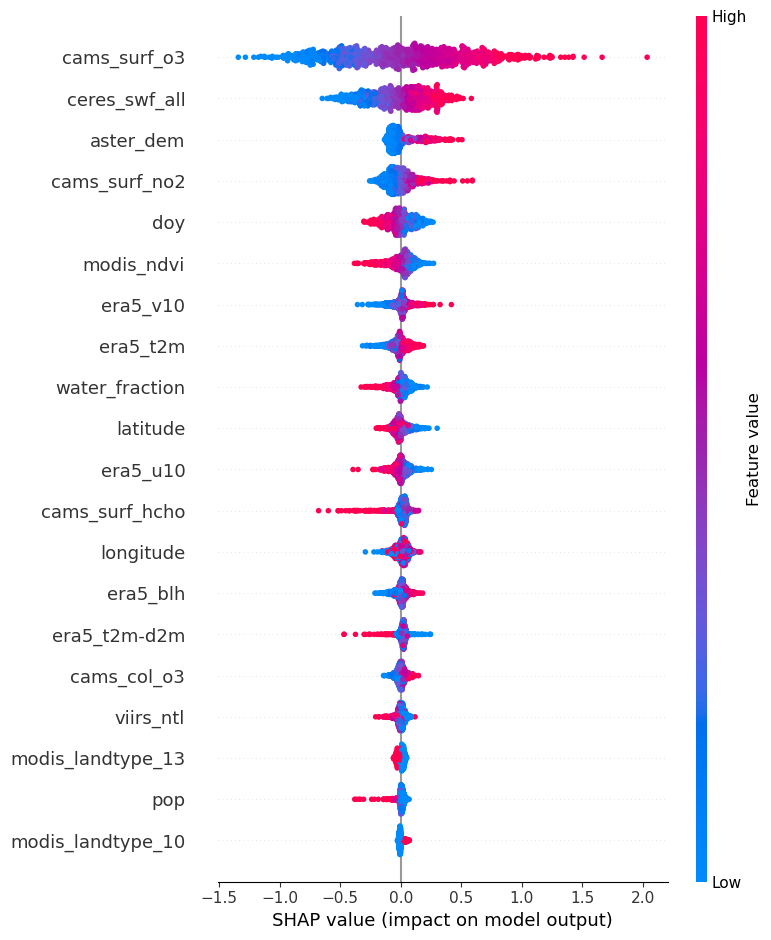

In [19]:
# =============================================================================
# SHAP analysis for trained MLP
# =============================================================================

import shap
import matplotlib.pyplot as plt


SHAP_ON = True

if SHAP_ON:

    print("=" * 90)
    print("                                  - SHAP analysis -")
    print("=" * 90)

    SHAP_PATH = SAVE_PATH / "SHAP"
    SHAP_PATH.mkdir(parents=True, exist_ok=True)

    # -------------------------------------------------------------------------
    # SHAP sample configuration
    # -------------------------------------------------------------------------
    n_background = 200   # samples used as SHAP reference/background
    n_explain = 1000     # samples to explain
    random_seed = 42

    rng = np.random.default_rng(random_seed)

    model.eval()

    # -------------------------------------------------------------------------
    # Use training data as background and test data for explanation
    # -------------------------------------------------------------------------
    X_train = data_train.x.float()
    X_test = data_test.x.float()

    n_train = X_train.shape[0]
    n_test = X_test.shape[0]

    background_idx = rng.choice(
        n_train,
        size=min(n_background, n_train),
        replace=False,
    )

    explain_idx = rng.choice(
        n_test,
        size=min(n_explain, n_test),
        replace=False,
    )

    background = X_train[background_idx].to(device)
    X_explain = X_test[explain_idx].to(device)

    X_explain_np = X_explain.detach().cpu().numpy()

    print(f" - Background samples : {background.shape[0]}")
    print(f" - Explained samples  : {X_explain.shape[0]}")
    print(f" - Number of features : {X_explain.shape[1]}")

    # -------------------------------------------------------------------------
    # Run SHAP GradientExplainer
    # -------------------------------------------------------------------------
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(X_explain)

    # -------------------------------------------------------------------------
    # Clean SHAP output shape
    # For one-output regression, final shape should be:
    # [n_samples, n_features]
    # -------------------------------------------------------------------------
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        if shap_values.shape[-1] == 1:
            shap_values = shap_values[:, :, 0]
        elif shap_values.shape[0] == 1:
            shap_values = shap_values[0]

    print(f" - SHAP values shape  : {shap_values.shape}")

    # -------------------------------------------------------------------------
    # Save SHAP values and explained feature values
    # -------------------------------------------------------------------------
    shap_df = pd.DataFrame(shap_values, columns=order_feat)
    shap_df.to_csv(SHAP_PATH / "shap_values.csv", index=False)

    feature_df = pd.DataFrame(X_explain_np, columns=order_feat)
    feature_df.to_csv(SHAP_PATH / "shap_feature_values_normalized.csv", index=False)

    # -------------------------------------------------------------------------
    # Global SHAP feature importance
    # -------------------------------------------------------------------------
    shap_importance = pd.DataFrame({
        "feature": order_feat,
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
        "mean_shap": np.mean(shap_values, axis=0),
    })

    shap_importance = shap_importance.sort_values(
        "mean_abs_shap",
        ascending=False,
    )

    shap_importance.to_csv(
        SHAP_PATH / "shap_feature_importance.csv",
        index=False,
    )

    print()
    print(" - Top SHAP features")
    print(shap_importance.head(20).to_string(index=False))

    # -------------------------------------------------------------------------
    # SHAP bar plot
    # -------------------------------------------------------------------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_explain_np,
        feature_names=order_feat,
        plot_type="bar",
        max_display=20,
        show=False,
    )
    plt.tight_layout()
    plt.savefig(SHAP_PATH / "shap_summary_bar.png", dpi=300, bbox_inches="tight")
    plt.close()

    # -------------------------------------------------------------------------
    # SHAP beeswarm plot
    # -------------------------------------------------------------------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_explain_np,
        feature_names=order_feat,
        max_display=20,
        show=False,
    )
    plt.tight_layout()
#     plt.savefig(SHAP_PATH / "shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
#     plt.close()

#     print()
#     print(f" - SHAP results saved to: {SHAP_PATH}")